보스턴 데이터셋의 특징 출력

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.optim.adam import Adam
# Load the Boston dataset from the URL

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


# Process the data to format it correctly
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Create a DataFrame to work with the dataset more easily
df = pd.DataFrame(data, columns=["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"])
df['MEDV'] = target

# Display first few rows of the dataset
print(df.head())

# Check for NaN values in the DataFrame
nan_check = df.isnull().any()

# Display which columns have NaN values
print(nan_check)

# To count the number of NaN values in each column, use:
nan_count = df.isnull().sum()
print(nan_count)
# Display column names (which represent the feature names)
print("Feature names:", df.columns)

# Alternatively, you can also view the first few rows to inspect the structure
print(df.head())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
CRIM       False
ZN         False
INDUS      False
CHAS       False
NOX        False
RM         False
AGE        False
DIS        False
RAD        False
TAX        False
PTRATIO    False
B          False
LSTAT      False
MEDV       False
dtype: bool
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD

In [ ]:
!pip install yfinance


In [ ]:
import yfinance as yf

# Define the ticker symbol for the company you're interested in (e.g., 'AAPL' for Apple)
ticker = 'AAPL'

# Download historical data
data = yf.download(ticker, start="2020-01-01", end="2023-01-01")

# Display the data
print(data.head())


[*********************100%***********************]  1 of 1 completed

Price                      Adj Close      Close       High        Low  \
Ticker                          AAPL       AAPL       AAPL       AAPL   
Date                                                                    
2020-01-02 00:00:00+00:00  72.876122  75.087502  75.150002  73.797501   
2020-01-03 00:00:00+00:00  72.167595  74.357498  75.144997  74.125000   
2020-01-06 00:00:00+00:00  72.742668  74.949997  74.989998  73.187500   
2020-01-07 00:00:00+00:00  72.400543  74.597504  75.224998  74.370003   
2020-01-08 00:00:00+00:00  73.565193  75.797501  76.110001  74.290001   

Price                           Open     Volume  
Ticker                          AAPL       AAPL  
Date                                             
2020-01-02 00:00:00+00:00  74.059998  135480400  
2020-01-03 00:00:00+00:00  74.287498  146322800  
2020-01-06 00:00:00+00:00  73.447502  118387200  
2020-01-07 00:00:00+00:00  74.959999  108872000  
2020-01-08 00:00:00+00:00  74.290001  132079200  


[*********************100%***********************]  1 of 1 completed


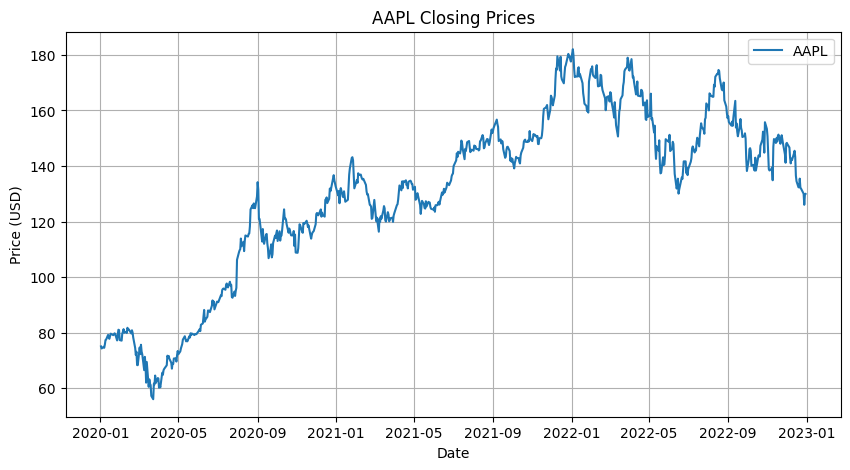

[*********************100%***********************]  1 of 1 completed


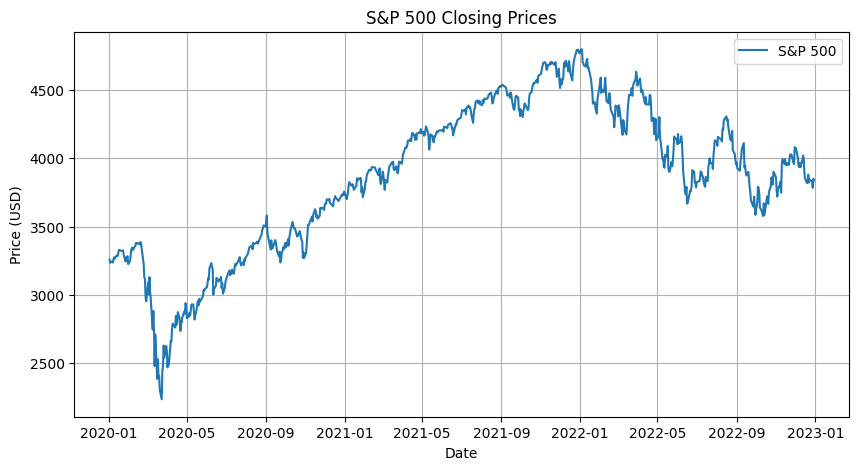

[*********************100%***********************]  1 of 1 completed


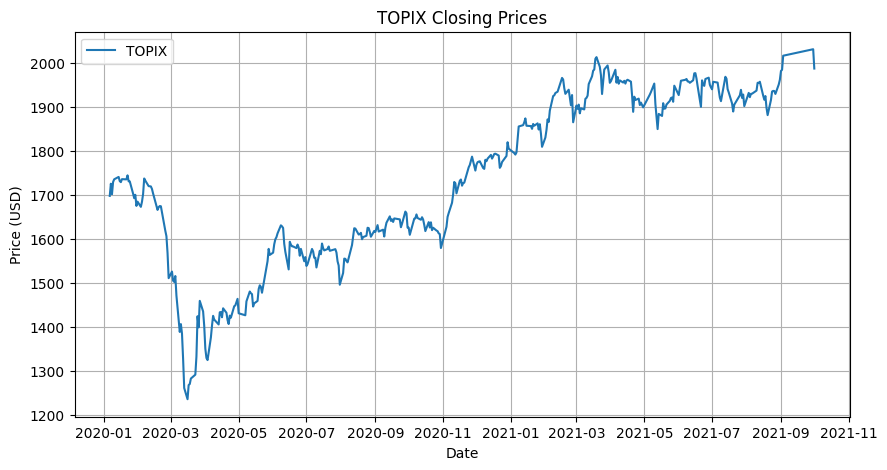

[*********************100%***********************]  1 of 1 completed


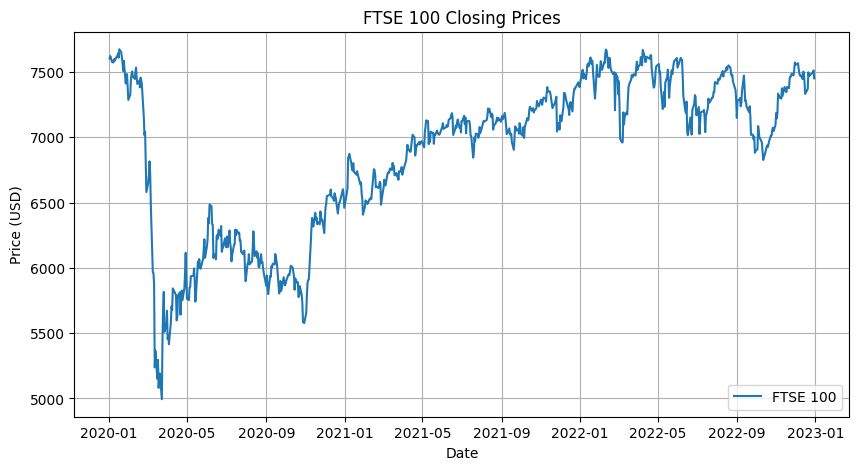

[*********************100%***********************]  1 of 1 completed


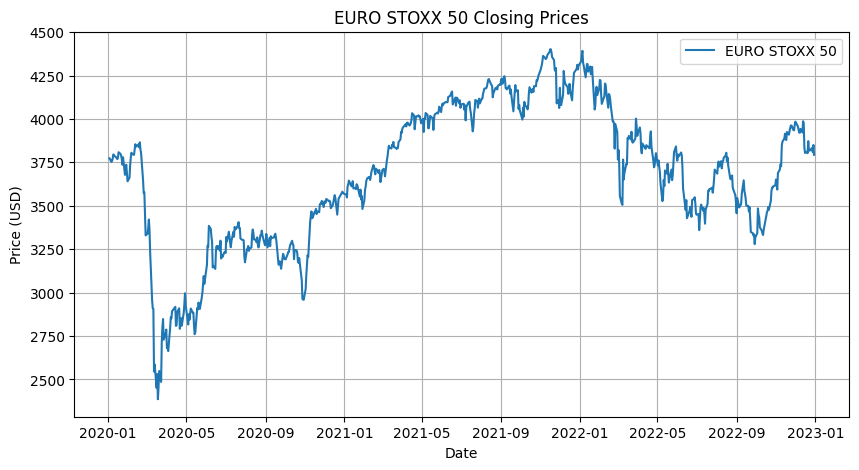

[*********************100%***********************]  1 of 1 completed


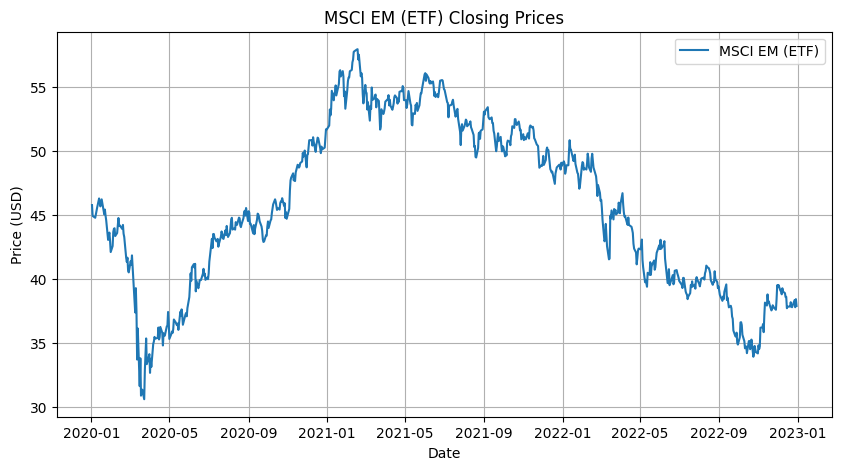

[*********************100%***********************]  1 of 1 completed


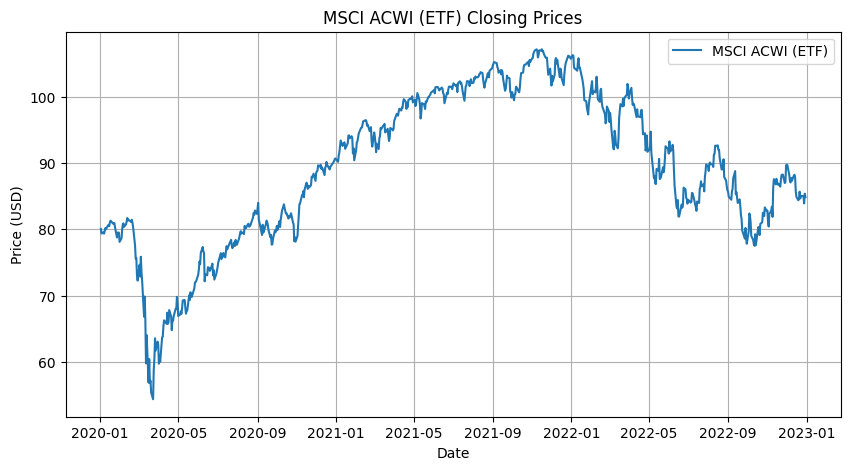

[*********************100%***********************]  1 of 1 completed


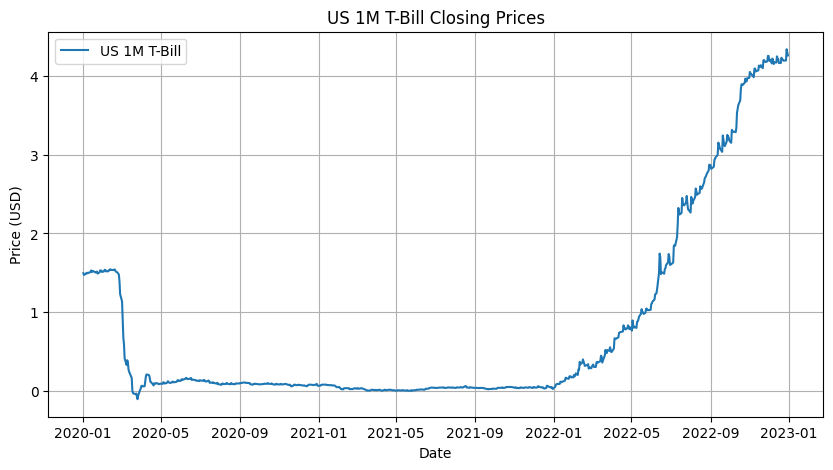

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

# Define the tickers dictionary
tickers = {
    "AAPL": 'AAPL',
    "S&P 500": '^GSPC',
    "TOPIX": '^TOPX',
    "FTSE 100": '^FTSE',
    "EURO STOXX 50": '^STOXX50E',
    "MSCI EM (ETF)": 'EEM',  # Alternative for MSCI EM
    "MSCI ACWI (ETF)": 'ACWI',  # Alternative for MSCI ACWI
    "US 1M T-Bill": '^IRX'
}

# Define the start and end dates
start_date = "2020-01-01"
end_date = "2023-01-01"

# Download historical data for each ticker and plot the closing prices
for name, ticker in tickers.items():
    try:
        # Download the data
        data = yf.download(ticker, start=start_date, end=end_date)

        # Check if the data is empty
        if data.empty:
            print(f"No data available for {name} ({ticker})")
            continue

        # Plot the closing price
        plt.figure(figsize=(10, 5))
        plt.plot(data['Close'], label=name)
        plt.title(f'{name} Closing Prices')
        plt.xlabel('Date')
        plt.ylabel('Price (USD)')
        plt.legend()
        plt.grid()
        plt.show()

    except Exception as e:
        print(f"Failed to download data for {name} ({ticker}): {e}")


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define the tickers for stocks and market index
tickers = {
    "AAPL": 'AAPL',
    "S&P 500": '^GSPC',
    "TOPIX": '^TOPX',
    "FTSE 100": '^FTSE',
    "EURO STOXX 50": '^STOXX50E',
    "MSCI EM (ETF)": 'EEM',
    "MSCI ACWI (ETF)": 'ACWI',
    "US 1M T-Bill": '^IRX'
}

# Define start and end dates
start_date = "2020-01-01"
end_date = "2023-01-01"
# Download historical data
data = yf.download(list(tickers.values()), start=start_date, end=end_date)['Adj Close']

# Calculate daily returns
returns = data.pct_change(fill_method=None).dropna()  # Specify fill_method=None to avoid warning

# Resample to monthly returns using 'ME' for month-end
monthly_returns = returns.resample('ME').agg(lambda x: (1 + x).prod() - 1)  # Calculate monthly returns

# Calculate the risk-free rate (assume constant for simplicity)
risk_free_rate = 0.01 / 12  # Annual risk-free rate divided by 12 months

# Calculate annualized returns from monthly returns (excluding the risk-free rate)
annualized_returns = (1 + monthly_returns.mean())**12 - 1
annualized_returns = annualized_returns[:-1]  # Exclude the risk-free return

# Calculate the covariance matrix of monthly returns (excluding the risk-free rate)
covariance_matrix = monthly_returns.cov() * 12  # Annualize the covariance matrix
covariance_matrix = covariance_matrix.values[:-1, :-1]  # Exclude the risk-free rate from covariance

# Define the Sharpe Ratio function
def sharpe_ratio(weights, returns, risk_free_rate):
    portfolio_return = np.dot(weights, annualized_returns)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(covariance_matrix, weights)))
    return -(portfolio_return - risk_free_rate) / portfolio_std_dev  # Minimize negative Sharpe Ratio

# Constraints: weights must sum to 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Bounds for each weight (between 0 and 1)
bounds = tuple((0, 1) for _ in range(len(annualized_returns)))  # Use the correct number of weights

# Initial guess (equal distribution)
initial_weights = np.array([1/(len(annualized_returns))] * len(annualized_returns))

# Optimize to find the best weights
optimal = minimize(sharpe_ratio, initial_weights, args=(monthly_returns, risk_free_rate),
                   method='SLSQP', bounds=bounds, constraints=constraints)

# Get optimal weights
optimal_weights = optimal.x
print("\nOptimal Weights to Maximize Sharpe Ratio:")
for ticker, weight in zip(list(tickers.keys())[:-1], optimal_weights):  # Exclude risk-free rate
    print(f"{ticker}: {weight:.4f}")

# Calculate the expected return and risk of the optimal portfolio
optimal_return = np.dot(optimal_weights, annualized_returns)
optimal_std_dev = np.sqrt(np.dot(optimal_weights.T, np.dot(covariance_matrix, optimal_weights)))

print(f"\nExpected Return of Optimal Portfolio: {optimal_return:.4f}")
print(f"Standard Deviation of Optimal Portfolio: {optimal_std_dev:.4f}")

# Calculate the Sharpe Ratio for the optimal portfolio
optimal_sharpe_ratio = (optimal_return - risk_free_rate) / optimal_std_dev
print(f"Optimal Sharpe Ratio: {optimal_sharpe_ratio:.4f}")


[*********************100%***********************]  8 of 8 completed



Optimal Weights to Maximize Sharpe Ratio:
AAPL: 0.3706
S&P 500: 0.0000
TOPIX: 0.0000
FTSE 100: 0.0000
EURO STOXX 50: 0.6294
MSCI EM (ETF): 0.0000
MSCI ACWI (ETF): 0.0000

Expected Return of Optimal Portfolio: 0.2752
Standard Deviation of Optimal Portfolio: 0.1496
Optimal Sharpe Ratio: 1.8334


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Define the tickers for stocks and market index
tickers = {
    "AAPL": 'AAPL',
    "S&P 500": '^GSPC',
    "TOPIX": '^TOPX',
    "FTSE 100": '^FTSE',
    "EURO STOXX 50": '^STOXX50E',
    "MSCI EM (ETF)": 'EEM',
    "MSCI ACWI (ETF)": 'ACWI',
    "US 1M T-Bill": '^IRX'
}

# Define start and end dates
start_date = "2020-01-01"
end_date = "2023-01-01"

# Download historical data
data = yf.download(list(tickers.values()), start=start_date, end=end_date)

# Calculate monthly returns
monthly_returns = data['Close'].pct_change().resample('M').agg(lambda x: (1 + x).prod() - 1).dropna()

# Calculate annualized monthly returns
annualized_monthly_returns = (1 + monthly_returns.mean()) ** 12 - 1

# Calculate the covariance matrix of monthly returns
covariance_matrix = monthly_returns.cov()  # No need to exclude the risk-free rate here

# Calculate the correlation matrix of monthly returns
correlation_matrix = monthly_returns.corr()  # No need to exclude the risk-free rate here

# Print results
print("Annualized Monthly Returns:")
print(annualized_monthly_returns)

print("\nCovariance Matrix (Monthly):")
print(covariance_matrix)

print("\nCorrelation Matrix (Monthly):")
print(correlation_matrix)

# Define the risk-free rate (annualized)
risk_free_rate = 0.01  # Example risk-free rate (1%)

# Define the Sharpe Ratio function
def sharpe_ratio(weights, returns, risk_free_rate):
    portfolio_return = np.dot(weights, annualized_monthly_returns)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(covariance_matrix.values, weights)))
    return -(portfolio_return - risk_free_rate) / portfolio_std_dev  # Minimize negative Sharpe Ratio

# Constraints: weights must sum to 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Bounds for each weight (between 0 and 1)
num_stocks = len(annualized_monthly_returns)
bounds = tuple((0, 1) for _ in range(num_stocks))

# Initial guess (equal distribution)
initial_weights = np.array([1 / num_stocks] * num_stocks)

# Optimize to find the best weights
optimal = minimize(sharpe_ratio, initial_weights, args=(monthly_returns, risk_free_rate),
                   method='SLSQP', bounds=bounds, constraints=constraints)

# Get optimal weights
optimal_weights = optimal.x
print("\nOptimal Weights to Maximize Sharpe Ratio:")
for ticker, weight in zip(list(tickers.keys())[:-1], optimal_weights):  # Exclude risk-free rate
    print(f"{ticker}: {weight:.4f}")

# Calculate the expected return and risk of the optimal portfolio
optimal_return = np.dot(optimal_weights, annualized_monthly_returns)
optimal_std_dev = np.sqrt(np.dot(optimal_weights.T, np.dot(covariance_matrix.values, optimal_weights)))

print(f"\nExpected Return of Optimal Portfolio: {optimal_return:.4f}")
print(f"Standard Deviation of Optimal Portfolio: {optimal_std_dev:.4f}")

# Calculate the Sharpe Ratio for the optimal portfolio
optimal_sharpe_ratio = (optimal_return - risk_free_rate) / optimal_std_dev
print(f"Optimal Sharpe Ratio: {optimal_sharpe_ratio:.4f}")


[*********************100%***********************]  8 of 8 completed
<ipython-input-44-07b720131d9b>:26: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_returns = data['Close'].pct_change().resample('M').agg(lambda x: (1 + x).prod() - 1).dropna()
<ipython-input-44-07b720131d9b>:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = data['Close'].pct_change().resample('M').agg(lambda x: (1 + x).prod() - 1).dropna()


Annualized Monthly Returns:
Ticker
AAPL          0.264940
ACWI          0.039916
EEM          -0.041601
^FTSE         0.005830
^GSPC         0.079541
^IRX         37.169155
^STOXX50E     0.026367
^TOPX         0.062787
dtype: float64

Covariance Matrix (Monthly):
Ticker         AAPL      ACWI       EEM     ^FTSE     ^GSPC      ^IRX  \
Ticker                                                                  
AAPL       0.009360  0.004081  0.002595  0.002025  0.004697  0.010165   
ACWI       0.004081  0.003347  0.002716  0.002170  0.003470  0.001758   
EEM        0.002595  0.002716  0.003466  0.001843  0.002511  0.006874   
^FTSE      0.002025  0.002170  0.001843  0.002113  0.002162  0.007339   
^GSPC      0.004697  0.003470  0.002511  0.002162  0.003733  0.003040   
^IRX       0.010165  0.001758  0.006874  0.007339  0.003040  1.186284   
^STOXX50E  0.003459  0.003318  0.002613  0.002720  0.003371  0.002322   
^TOPX      0.001174  0.001173  0.000917  0.001239  0.001166  0.004121   

Ticke

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


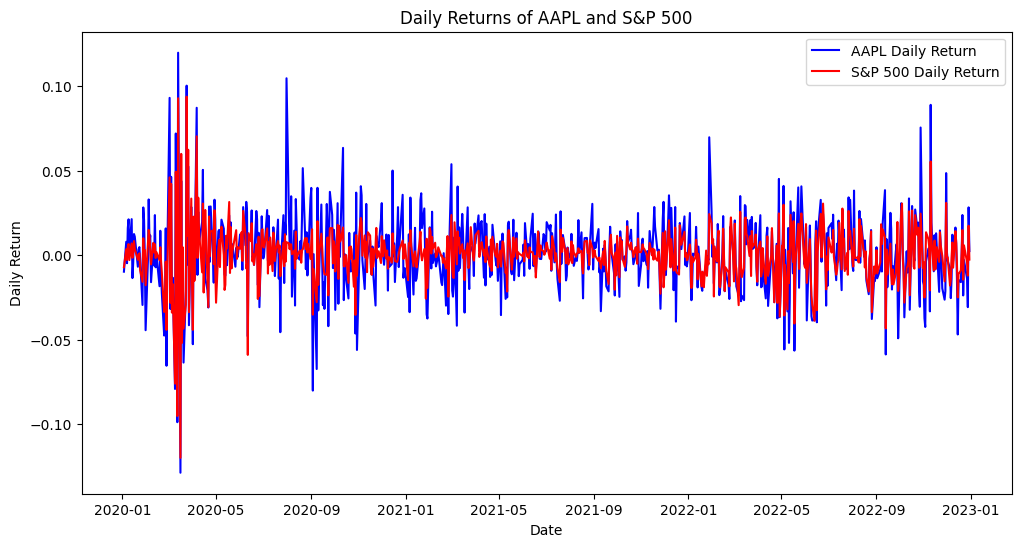

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

# Define ticker symbols
stock_ticker = 'AAPL'
index_ticker = '^GSPC'  # S&P 500

# Download historical data for both the stock and the S&P 500 index
stock_data = yf.download(stock_ticker, start="2020-01-01", end="2023-01-01")
index_data = yf.download(index_ticker, start="2020-01-01", end="2023-01-01")

# Calculate daily returns for the stock and the index
stock_data['Daily Return'] = stock_data['Close'].pct_change()
index_data['Daily Return'] = index_data['Close'].pct_change()

# Plot the daily returns
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Daily Return'], label=f"{stock_ticker} Daily Return", color='blue')
plt.plot(index_data['Daily Return'], label="S&P 500 Daily Return", color='red')
plt.title(f"Daily Returns of {stock_ticker} and S&P 500")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.show()


# 데이터의 구성요소 확인

In [ ]:
import pandas as pd
import numpy as np

# Load the Boston dataset from the URL
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Process the data to format it correctly
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Create a DataFrame to work with the dataset more easily
df = pd.DataFrame(data, columns=["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"])
df['MEDV'] = target

# Display the original DataFrame
print("Original DataFrame:")
print(df.head())

# 1 Load the data into a new DataFrame (this is already done)
dataFrame = pd.DataFrame(data, columns=["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"])

# 2 Since df already has the correct column names, you can skip this step
# You can directly add the target column
dataFrame["target"] = df['MEDV']  # Using the correct column for the target

# Display the new DataFrame
print("\nNew DataFrame:")
print(dataFrame.head())


Original DataFrame:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

New DataFrame:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0

# 선형회귀를 위한 MLP모델의 설계

In [ ]:
import torch
import torch.nn as nn

from torch.optim.adam import Adam


# ❶ 모델 정의
model = nn.Sequential(
    nn.Linear(13, 100),  # Input layer to first hidden layer
    nn.ReLU(),           # Activation function
    nn.Linear(100, 50),  # Second hidden layer
    nn.ReLU(),           # Activation function
    nn.Linear(50, 25),   # Third hidden layer
    nn.ReLU(),           # Activation function
    nn.Linear(25, 1)     # Output layer
)

X = dataFrame.iloc[:, :13].values # ❷ 정답을 제외한 특징을 X에 입력
Y = dataFrame["target"].values    # 데이터프레임의 target의 값을 추출

batch_size = 100
learning_rate = 0.01

# ❸ 가중치를 수정하기 위한 최적화 정의
optim = Adam(model.parameters(), lr=learning_rate)


# 에포크 반복
for epoch in range(2050):

   # 배치 반복
   for i in range(len(X)//batch_size):
       start = i*batch_size      # ➍ 배치 크기에 맞게 인덱스를 지정
       end = start + batch_size


       # 파이토치 실수형 텐서로 변환
       x = torch.FloatTensor(X[start:end])
       y = torch.FloatTensor(Y[start:end])

       optim.zero_grad() # ❺ 가중치의 기울기를 0으로 초기화
       preds = model(x)  # ❻ 모델의 예측값 계산
       loss = nn.MSELoss()(preds, y) # ❼ MSE 손실 계산
       loss.backward()
       optim.step()

   if epoch % 20 == 0:
       print(f"epoch{epoch} loss:{loss.item()}")


epoch0 loss:146.0226287841797


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([100])) that is different to the input size (torch.Size([100, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch20 loss:40.65256118774414
epoch40 loss:39.26725769042969
epoch60 loss:40.19334411621094
epoch80 loss:44.12607955932617
epoch100 loss:39.799381256103516
epoch120 loss:38.63809585571289
epoch140 loss:37.65935516357422
epoch160 loss:37.08683776855469
epoch180 loss:36.370330810546875
epoch200 loss:36.38291549682617
epoch220 loss:36.078670501708984
epoch240 loss:35.68513870239258
epoch260 loss:35.62688446044922
epoch280 loss:35.91903305053711
epoch300 loss:35.598392486572266
epoch320 loss:36.00876998901367
epoch340 loss:36.05816650390625
epoch360 loss:34.60760498046875
epoch380 loss:39.103912353515625
epoch400 loss:57.7741813659668
epoch420 loss:36.56352996826172
epoch440 loss:36.06636428833008
epoch460 loss:35.96937561035156
epoch480 loss:35.41646194458008
epoch500 loss:35.258270263671875
epoch520 loss:36.57252502441406
epoch540 loss:35.197322845458984
epoch560 loss:33.874473571777344
epoch580 loss:33.23800277709961
epoch600 loss:33.037818908691406
epoch620 loss:32.3818359375
epoch640

# 모델 성능 평가

In [ ]:
# Switch model to evaluation mode
model.eval()

# Make sure to use unsqueeze to convert the 1D tensor to 2D
prediction = model(torch.FloatTensor(X[0, :13]).unsqueeze(0))  # Add a batch dimension
real = Y[0]
print(f"prediction: {prediction.item()} real: {real}")


prediction: 22.050315856933594 real: 24.0


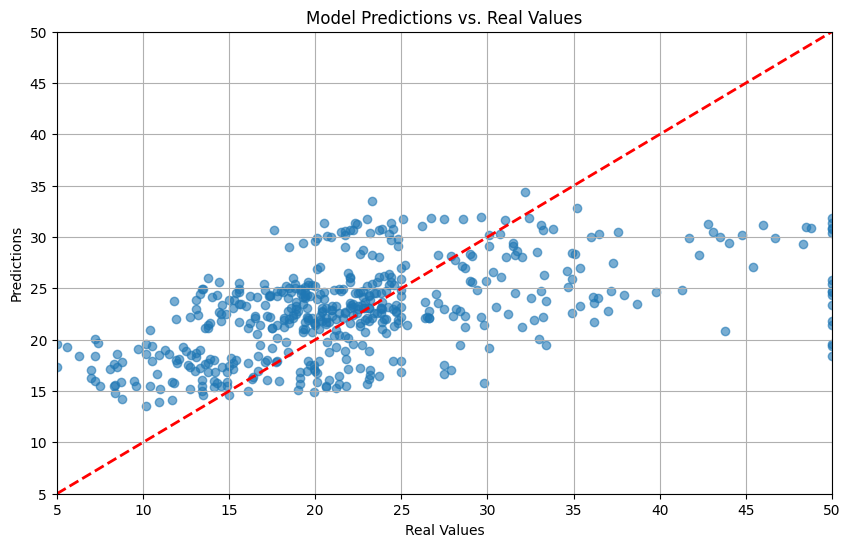

In [ ]:
import torch
import matplotlib.pyplot as plt

# Set the model to evaluation mode
model.eval()

# Prepare lists to store predictions and real values
predictions = []
real_values = []

# Iterate over the dataset (assuming X is in the right shape)
for i in range(len(X)):
    input_tensor = torch.FloatTensor(X[i, :13]).unsqueeze(0)  # Add batch dimension
    prediction = model(input_tensor)
    real = Y[i]

    # Append the prediction and the real value to the lists
    predictions.append(prediction.item())
    real_values.append(real)

# Now let's plot the predictions against the real values
plt.figure(figsize=(10, 6))
plt.scatter(real_values, predictions, alpha=0.6)
plt.plot([min(real_values), max(real_values)], [min(real_values), max(real_values)], color='red', linestyle='--', linewidth=2)
plt.title('Model Predictions vs. Real Values')
plt.xlabel('Real Values')
plt.ylabel('Predictions')
plt.xlim(min(real_values), max(real_values))
plt.ylim(min(real_values), max(real_values))
plt.grid(True)
plt.show()
